In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("cleaned_bearing_data.csv", parse_dates=["subscription_start", "timestamp_of_fault"])

# Compute operational days
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days
df = df[df['operational_days'].notna()]


In [2]:
# Select features for modeling
features = [
    'industry_type', 'machine_type', 'speed_type', 'bearing_type_assigned_1',
    'lubrication_method'
]

df_model = df[features + ['operational_days']].dropna()

# Label encoding
encoders = {}
for col in features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le


In [3]:
X = df_model[features]
y = df_model['operational_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)


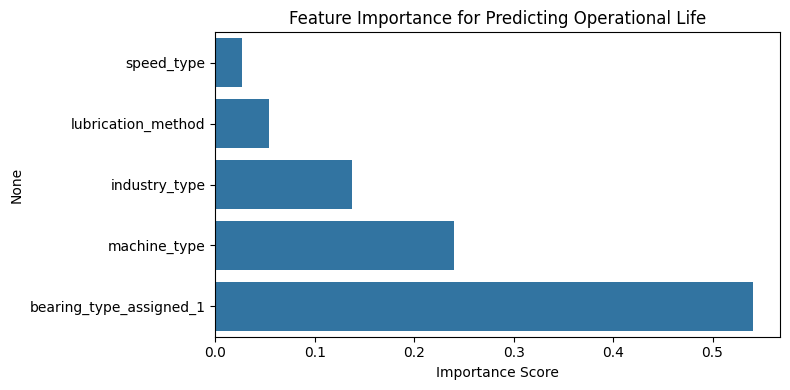

In [5]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
sns.barplot(x=importances, y=importances.index)
plt.title("Feature Importance for Predicting Operational Life")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("outputs/q8/feature_importance.png")
plt.show()

# Save for app
importances.to_csv("outputs/q8/feature_importance.csv")


In [6]:
with open("outputs/q8/model_metrics.txt", "w") as f:
    f.write(f"R2 Score: {r2:.3f}\nMAE: {mae:.2f} days")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Load and preprocess ---
df = pd.read_csv("cleaned_bearing_data.csv", parse_dates=["subscription_start", "timestamp_of_fault"])
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days
df = df[df['operational_days'].notna()]

# --- Add RPM range buckets ---
def rpm_bucket(rpm):
    if pd.isna(rpm):
        return np.nan
    elif rpm < 500:
        return "Low"
    elif rpm < 1500:
        return "Medium"
    else:
        return "High"

df['rpm_range'] = df['rpm_min'].apply(rpm_bucket)

# --- Select features ---
features = [
    'industry_type', 'machine_type', 'speed_type',
    'bearing_type_assigned_1', 'lubrication_method', 'rpm_range'
]
df_model = df[features + ['operational_days']].dropna()

# --- Encode categorical features ---
encoders = {}
for col in features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

# --- Train/test split ---
X = df_model[features]
y = df_model['operational_days']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# --- Train model ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- Evaluation ---
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# --- Save metrics ---
os.makedirs("outputs/q8", exist_ok=True)
with open("outputs/q8/model_metrics.txt", "w") as f:
    f.write(f"""Random Forest Model Performance:

R² Score:        {r2:.4f}
MAE:             {mae:.2f} days
RMSE:            {rmse:.2f} days
MAPE:            {mape:.2f}%
Test Samples:    {len(y_test)}
""")

# --- Feature Importance ---
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
fi.to_csv("outputs/q8/feature_importance.csv")

plt.figure(figsize=(8, 4))
sns.barplot(x=fi, y=fi.index)
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("outputs/q8/feature_importance.png")
plt.close()

# --- Residual Plot ---
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residuals (days)")
plt.tight_layout()
plt.savefig("outputs/q8/residual_hist.png")
plt.close()

# --- Actual vs Predicted Plot ---
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "--", color="gray")
plt.title("Actual vs Predicted")
plt.xlabel("Actual Operational Days")
plt.ylabel("Predicted Operational Days")
plt.tight_layout()
plt.savefig("outputs/q8/actual_vs_predicted.png")
plt.close()

# --- SHAP Explanation ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features, show=False, plot_type="bar")
plt.tight_layout()
plt.savefig("outputs/q8/shap_summary_bar.png")
plt.close()

shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.tight_layout()
plt.savefig("outputs/q8/shap_summary_dot.png")
plt.close()

# --- Permutation Importance ---
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=True)

perm_df.to_csv("outputs/q8/permutation_importance.csv", index=False)

plt.figure(figsize=(8, 4))
sns.barplot(x="Importance", y="Feature", data=perm_df)
plt.title("Permutation Importance")
plt.tight_layout()
plt.savefig("outputs/q8/permutation_importance.png")
plt.close()


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --- Load and preprocess ---
df = pd.read_csv("cleaned_bearing_data.csv", parse_dates=["subscription_start", "timestamp_of_fault"])
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days
df = df[df['operational_days'].notna()]

# --- Add RPM range buckets ---
def rpm_bucket(rpm):
    if pd.isna(rpm):
        return np.nan
    elif rpm < 500:
        return "Low"
    elif rpm < 1500:
        return "Medium"
    else:
        return "High"

df['rpm_range'] = df['rpm_min'].apply(rpm_bucket)

# --- Select features ---
features = [
    'industry_type', 'machine_type', 'speed_type',
    'bearing_type_assigned_1', 'lubrication_method', 'rpm_range'
]
df_model = df[features + ['operational_days']].dropna()

# --- Encode categorical features ---
encoders = {}
for col in features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

# --- Train/test split ---
X = df_model[features]
y = df_model['operational_days']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# --- Train model ---
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- Evaluation ---
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# --- Save metrics ---
os.makedirs("outputs/q8", exist_ok=True)
with open("outputs/q8/model_metrics.txt", "w") as f:
    f.write(f"""Random Forest Model Performance:

R² Score:        {r2:.4f}
MAE:             {mae:.2f} days
RMSE:            {rmse:.2f} days
MAPE:            {mape:.2f}%
Test Samples:    {len(y_test)}
""")

# --- Feature Importance ---
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
fi.to_csv("outputs/q8/feature_importance.csv")

plt.figure(figsize=(8, 4))
sns.barplot(x=fi, y=fi.index)
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("outputs/q8/feature_importance.png")
plt.close()

# --- Residual Plot ---
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residuals (days)")
plt.tight_layout()
plt.savefig("outputs/q8/residual_hist.png")
plt.close()

# --- Actual vs Predicted Plot ---
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "--", color="gray")
plt.title("Actual vs Predicted")
plt.xlabel("Actual Operational Days")
plt.ylabel("Predicted Operational Days")
plt.tight_layout()
plt.savefig("outputs/q8/actual_vs_predicted.png")
plt.close()

# --- SHAP Explanation ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features, show=False, plot_type="bar")
plt.tight_layout()
plt.savefig("outputs/q8/shap_summary_bar.png")
plt.close()

shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.tight_layout()
plt.savefig("outputs/q8/shap_summary_dot.png")
plt.close()

# --- Permutation Importance ---
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=True)

perm_df.to_csv("outputs/q8/permutation_importance.csv", index=False)

plt.figure(figsize=(8, 4))
sns.barplot(x="Importance", y="Feature", data=perm_df)
plt.title("Permutation Importance")
plt.tight_layout()
plt.savefig("outputs/q8/permutation_importance.png")
plt.close()
